<a href="https://colab.research.google.com/github/CuicuiZhang01/Cuicui__INFO5731_Spring2026/blob/main/Zhang_Cuicui_Assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [ ]:
!pip install bertopic
!pip install sentence-transformers
!pip install umap-learn
!pip install hdbscan
!pip install gensim
import nltk
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.2 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

import re
import nltk
from nltk.corpus import stopwords
import os
import warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

In [ ]:
# Load dataset
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

# Convert to DataFrame and sample 2000 documents
df = pd.DataFrame({'text': newsgroups.data})
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print("Number of documents:", len(df))

Number of documents: 2000


In [ ]:
# Text Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Apply cleaning
df['tokens'] = df['text'].apply(clean_text)
texts = df['tokens'].tolist()

# Create Dictionary
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Extract Topics
def get_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append(top_words)
    return topics

# Function to Compute Coherence
def compute_coherence(topics, texts, dictionary):
    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

In [ ]:
# Generate K =10 topics using LDA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Convert tokens back to text (for vectorizer)
docs = [" ".join(tokens) for tokens in texts]

# Vectorization (Bag of Words)
vectorizer = CountVectorizer(max_df=0.95, min_df=5)
X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

# Train LDA model
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
lda_model.fit(X)

# Extract topics
lda_topics = get_topics(lda_model, feature_names)

# Print topics
print("=== LDA Topics (K=10) ===")
for i, topic in enumerate(lda_topics):
    print(f"Topic {i}: {topic}")

# Compute coherence
lda_coherence = compute_coherence(lda_topics, texts, dictionary)
print(f"\nLDA Coherence Score: {lda_coherence:.4f}")

=== LDA Topics (K=10) ===
Topic 0: ['would', 'people', 'one', 'dont', 'think', 'god', 'like', 'good', 'know', 'even']
Topic 1: ['administration', 'would', 'president', 'government', 'think', 'us', 'well', 'official', 'program', 'senior']
Topic 2: ['armenian', 'la', 'armenians', 'people', 'pt', 'vs', 'israel', 'one', 'israeli', 'war']
Topic 3: ['use', 'may', 'new', 'gun', 'states', 'number', 'risk', 'national', 'reported', 'child']
Topic 4: ['dont', 'mr', 'said', 'going', 'ms', 'one', 'know', 'well', 'something', 'car']
Topic 5: ['would', 'like', 'get', 'insurance', 'make', 'car', 'problem', 'dont', 'food', 'also']
Topic 6: ['dos', 'please', 'available', 'windows', 'thanks', 'get', 'also', 'email', 'information', 'file']
Topic 7: ['would', 'new', 'time', 'one', 'war', 'team', 'south', 'game', 'last', 'year']
Topic 8: ['one', 'would', 'key', 'im', 'chip', 'use', 'know', 'clipper', 'get', 'buy']
Topic 9: ['bit', 'scsi', 'space', 'drive', 'mb', 'mac', 'card', 'one', 'os', 'disk']

LDA Cohe

In [ ]:
# LDA with Different K
lda_scores = []
k_values = [5, 10, 15, 20, 25, 30]

# Vectorizer for LDA
count_vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    stop_words='english'
)

X_counts = count_vectorizer.fit_transform(docs)
feature_names = count_vectorizer.get_feature_names_out()

results = []
for k in k_values:
    lda = LatentDirichletAllocation(n_components=k, random_state=42)
    lda.fit(X_counts)

    topics = get_topics(lda, feature_names)
    coherence = compute_coherence(topics, texts, dictionary)

    lda_scores.append(coherence)
    results.append((k, coherence))

print("\n=== LDA Results ===")
for k, score in results:
    print(f"K={k}, Coherence={score:.4f}")


=== LDA Results ===
K=5, Coherence=0.5207
K=10, Coherence=0.5761
K=15, Coherence=0.5375
K=20, Coherence=0.5310
K=25, Coherence=0.5308
K=30, Coherence=0.5436


In [ ]:
# Generate K=10 topics using LSA
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization (better for LSA)
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=5)
X_tfidf = tfidf_vectorizer.fit_transform(docs)
feature_names_lsa = tfidf_vectorizer.get_feature_names_out()

# Train LSA model
lsa_model = TruncatedSVD(n_components=10, random_state=42)
lsa_model.fit(X_tfidf)

# Extract topics
lsa_topics = get_topics(lsa_model, feature_names_lsa)

# Print topics
print("\n=== LSA Topics (K=10) ===")
for i, topic in enumerate(lsa_topics):
    print(f"Topic {i}: {topic}")

# Compute coherence
lsa_coherence = compute_coherence(lsa_topics, texts, dictionary)
print(f"\nLSA Coherence Score: {lsa_coherence:.4f}")


=== LSA Topics (K=10) ===
Topic 0: ['would', 'one', 'dont', 'know', 'get', 'like', 'people', 'im', 'think', 'could']
Topic 1: ['thanks', 'windows', 'please', 'email', 'card', 'anyone', 'advance', 'dos', 'file', 'drive']
Topic 2: ['gebcadredslpittedu', 'njxp', 'chastity', 'shameful', 'surrender', 'intellect', 'gordon', 'skepticism', 'banks', 'soon']
Topic 3: ['please', 'thanks', 'email', 'anyone', 'know', 'god', 'advance', 'address', 'would', 'reply']
Topic 4: ['god', 'windows', 'dos', 'believe', 'card', 'people', 'christians', 'jesus', 'file', 'files']
Topic 5: ['would', 'key', 'use', 'keys', 'encryption', 'government', 'chip', 'clipper', 'algorithm', 'escrow']
Topic 6: ['would', 'god', 'drive', 'email', 'one', 'please', 'controller', 'sale', 'card', 'ide']
Topic 7: ['would', 'windows', 'think', 'car', 'like', 'could', 'card', 'im', 'dos', 'really']
Topic 8: ['windows', 'dos', 'new', 'file', 'program', 'space', 'email', 'armenian', 'window', 'sale']
Topic 9: ['car', 'god', 'window', '

In [ ]:
# LSA with Different K
lsa_scores = []

# Vectorizer for LSA
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, stop_words='english' )
X_tfidf = tfidf_vectorizer.fit_transform(docs)
feature_names_lsa = tfidf_vectorizer.get_feature_names_out()

lsa_results = []

for k in k_values:
    lsa = TruncatedSVD(n_components=k, random_state=42)
    lsa.fit(X_tfidf)

    topics = get_topics(lsa, feature_names_lsa)
    coherence = compute_coherence(topics, texts, dictionary)

    lsa_scores.append(coherence)
    lsa_results.append((k, coherence))

print("\n=== LSA Results ===")
for k, score in lsa_results:
    print(f"K={k}, Coherence={score:.4f}")


=== LSA Results ===
K=5, Coherence=0.5262
K=10, Coherence=0.5340
K=15, Coherence=0.4311
K=20, Coherence=0.4295
K=25, Coherence=0.3848
K=30, Coherence=0.3547


In [ ]:
# Find Optimal K
best_k_lda = k_values[np.argmax(lda_scores)]
best_k_lsa = k_values[np.argmax(lsa_scores)]

print("\nBest K for LDA:", best_k_lda)
print("Best K for LSA:", best_k_lsa)


Best K for LDA: 10
Best K for LSA: 10


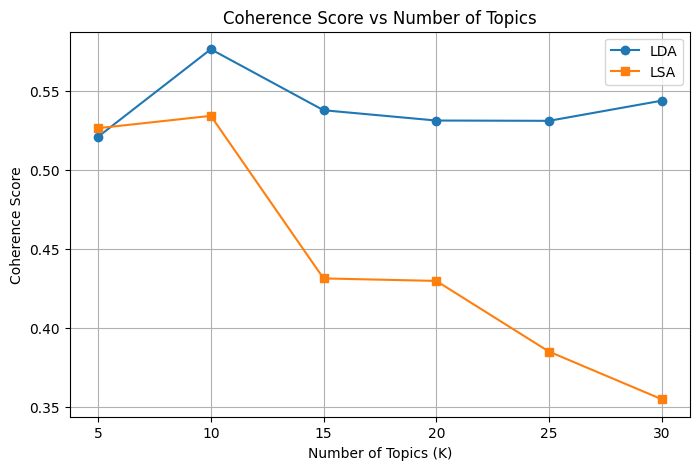

In [ ]:
# Visualization
plt.figure(figsize=(8, 5))

plt.plot(k_values, lda_scores, marker='o', label='LDA')
plt.plot(k_values, lsa_scores, marker='s', label='LSA')

plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Number of Topics")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Train Final Model (Best K Example: LDA)
lda_final = LatentDirichletAllocation(n_components=best_k_lda, random_state=42)
lda_final.fit(X_counts)

final_topics = get_topics(lda_final, feature_names)
 # Topic Summary
for i, topic in enumerate(final_topics):
    print(f"Topic {i}: {topic}")

Topic 0: ['available', 'version', 'motif', 'xr', 'server', 'subject', 'program', 'use', 'information', 'widget']
Topic 1: ['dos', 'south', 'war', 'new', 'time', 'secret', 'military', 'nuclear', 'island', 'naval']
Topic 2: ['key', 'use', 'space', 'email', 'windows', 'used', 'thanks', 'using', 'like', 'know']
Topic 3: ['scsi', 'bit', 'mac', 'card', 'mb', 'os', 'mhz', 'memory', 'ibm', 'mode']
Topic 4: ['windows', 'like', 'problem', 'window', 'drive', 'im', 'time', 'using', 'know', 'problems']
Topic 5: ['dont', 'know', 'mr', 'said', 'going', 'think', 'ms', 'president', 'people', 'im']
Topic 6: ['people', 'think', 'government', 'law', 'dont', 'make', 'right', 'say', 'like', 'way']
Topic 7: ['know', 'im', 'like', 'dont', 'think', 'game', 'people', 'car', 'thats', 'sure']
Topic 8: ['la', 'pt', 'vs', 'like', 'year', 'team', 'good', 'new', 'think', 'bike']
Topic 9: ['god', 'people', 'armenian', 'armenians', 'dead', 'attack', 'jesus', 'killed', 'christ', 'life']


#### LDA Topic Summaries
Topic 0:
This topic is about software systems and graphical interfaces, especially related to programs, servers, and tools like Motif and X Window systems.

Topic 1:
This topic focuses on military and geopolitical issues, including war, nuclear weapons, and naval or defense-related topics.

Topic 2:
This topic is about general computing and communication, including email, Windows usage, and basic technical discussions.

Topic 3:
This topic relates to computer hardware, such as memory, SCSI devices, processors, and system specifications.

Topic 4:
This topic focuses on Windows operating system problems and troubleshooting, including issues with drives and general usage.

Topic 5:
This topic is about political discussions and public opinions, involving government figures and general societal commentary.

Topic 6:
This topic centers on government, laws, and social debates, including opinions about rights and policies.

Topic 7:
This topic includes casual discussions and everyday conversations, covering mixed topics like games, cars, and personal opinions.

Topic 8:
This topic is about sports and teams, including games, performance, and possibly biking or competitions.

Topic 9:
This topic focuses on religion and historical conflict, including Christianity and references to Armenian-related events.

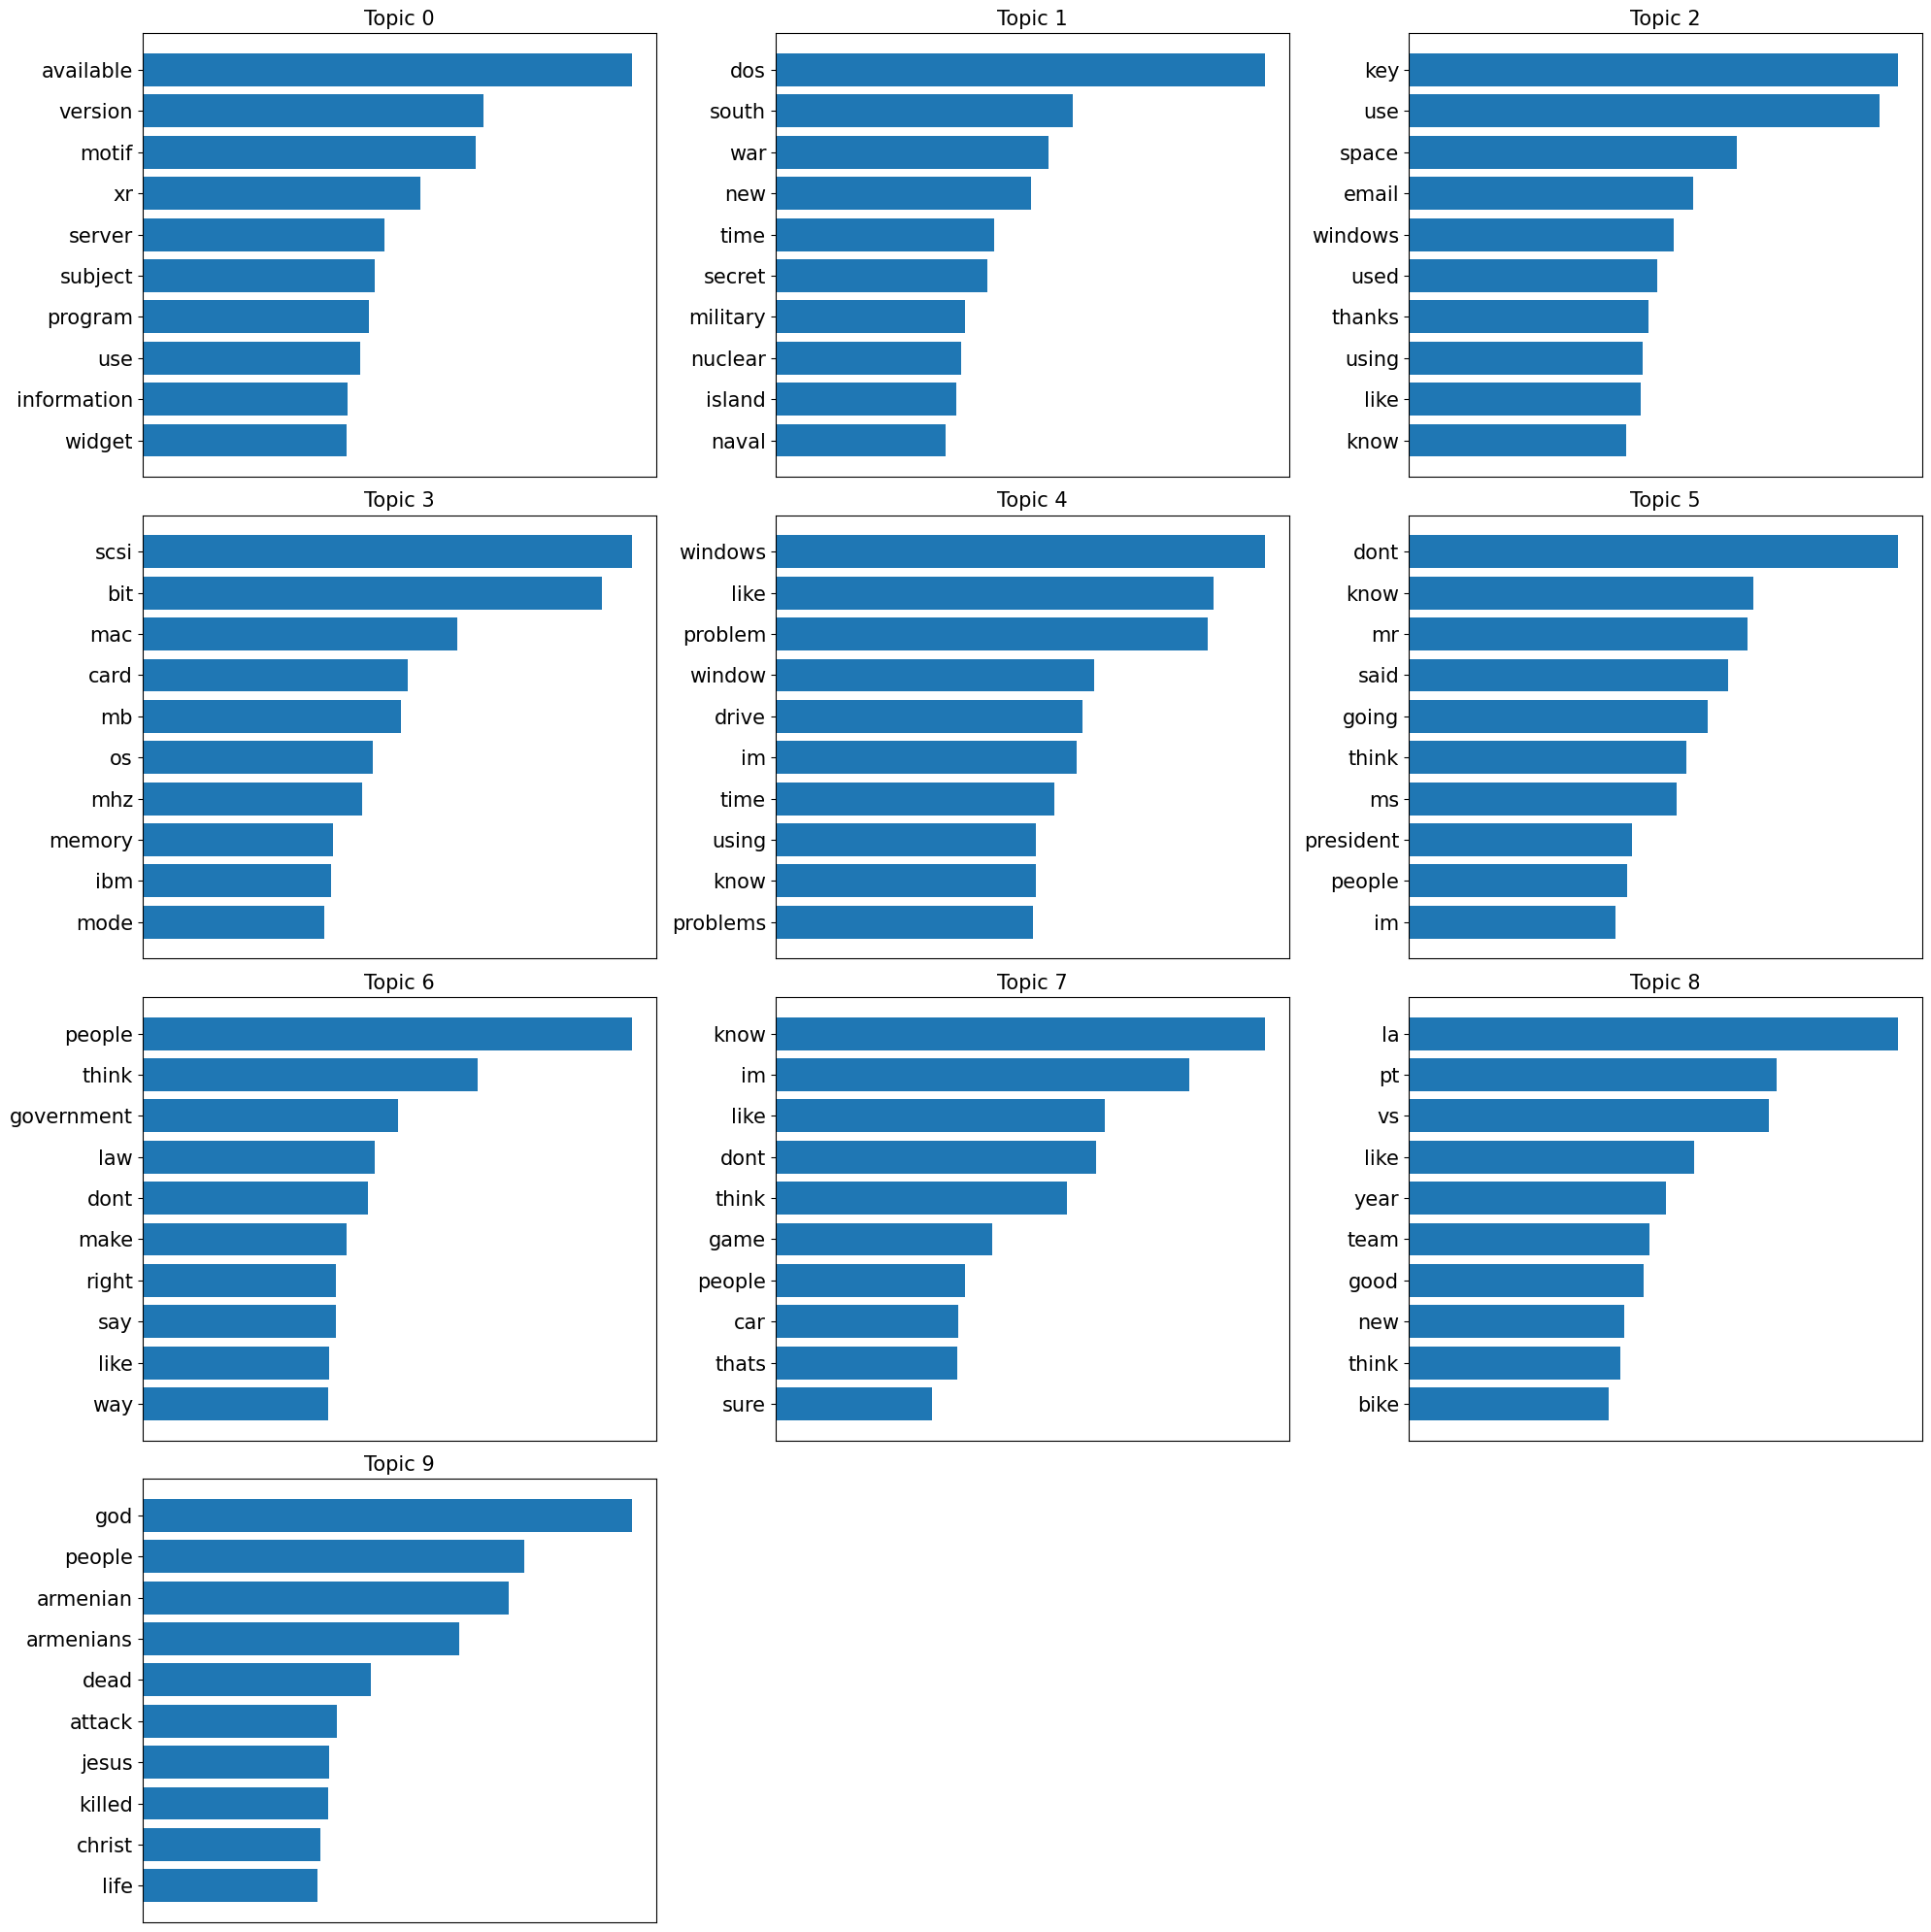

In [ ]:
# LDA Topic Visualization
import matplotlib.pyplot as plt

n_topics = len(final_topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols

plt.figure(figsize=(20, 20))

for i, topic in enumerate(final_topics):
    plt.subplot(n_rows, n_cols, i + 1)

    topic_weights = lda_final.components_[i]
    top_indices = topic_weights.argsort()[:-11:-1]

    words = [feature_names[j] for j in top_indices]
    scores = topic_weights[top_indices]

    plt.barh(words[::-1], scores[::-1])

    plt.title(f"Topic {i}", fontsize=15)
    plt.xticks([])
    plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
# Train Final Model (Best K Example: LSA)
lsa_final = TruncatedSVD(n_components=best_k_lsa, random_state=42)
lsa_final.fit(X_tfidf)

# Extract topics
final_topics_lsa = get_topics(lsa_final, feature_names_lsa)

# Topic Summary
for i, topic in enumerate(final_topics_lsa):
    print(f"Topic {i}: {topic}")

Topic 0: ['dont', 'know', 'people', 'like', 'im', 'think', 'time', 'good', 'thanks', 'use']
Topic 1: ['windows', 'thanks', 'card', 'email', 'dos', 'drive', 'file', 'advance', 'disk', 'program']
Topic 2: ['chastity', 'gebcadredslpittedu', 'njxp', 'shameful', 'surrender', 'intellect', 'gordon', 'skepticism', 'banks', 'soon']
Topic 3: ['god', 'windows', 'believe', 'christians', 'jesus', 'people', 'dos', 'christ', 'bible', 'thanks']
Topic 4: ['drive', 'dos', 'card', 'mb', 'scsi', 'windows', 'god', 'disk', 'controller', 'hard']
Topic 5: ['key', 'use', 'keys', 'government', 'chip', 'encryption', 'clipper', 'file', 'bit', 'using']
Topic 6: ['windows', 'im', 'dont', 'know', 'dos', 'think', 'file', 'window', 'running', 'like']
Topic 7: ['windows', 'dos', 'car', 'new', 'file', 'program', 'email', 'space', 'armenian', 'send']
Topic 8: ['car', 'god', 'window', 'im', 'cars', 'engine', 'problem', 'new', 'using', 'looking']
Topic 9: ['drive', 'dont', 'dos', 'disk', 'know', 'problems', 'hard', 'people

#### LSA Topic Summaries
Topic 0:
This topic represents general casual discussions, with common words like “people,” “think,” and “know,” indicating informal conversations without a clear specific theme.

Topic 1:
This topic is about computer systems and file management, including Windows, DOS, disks, drives, and programs.

Topic 2:
This topic appears to involve philosophical or critical discussions, possibly about skepticism, intellect, and personal opinions, though it is somewhat noisy and less coherent.

Topic 3:
This topic focuses on religion and belief systems, especially Christianity, including God, Jesus, and the Bible.

Topic 4:
This topic relates to computer hardware and storage devices, such as hard drives, SCSI, controllers, and system components.

Topic 5:
This topic is about encryption and government policies, including topics like keys, cryptography, and the Clipper chip.

Topic 6:
This topic represents Windows/DOS usage and troubleshooting, including running programs and handling files.

Topic 7:
This topic includes mixed technical and general discussions, combining computing, communication (email), and some unrelated terms, indicating a less focused topic.

Topic 8:
This topic is about cars and mechanical issues, including engines, problems, and usage.

Topic 9:
This topic focuses on disk and drive-related problems, especially issues with hard drives, IDE, and system errors.

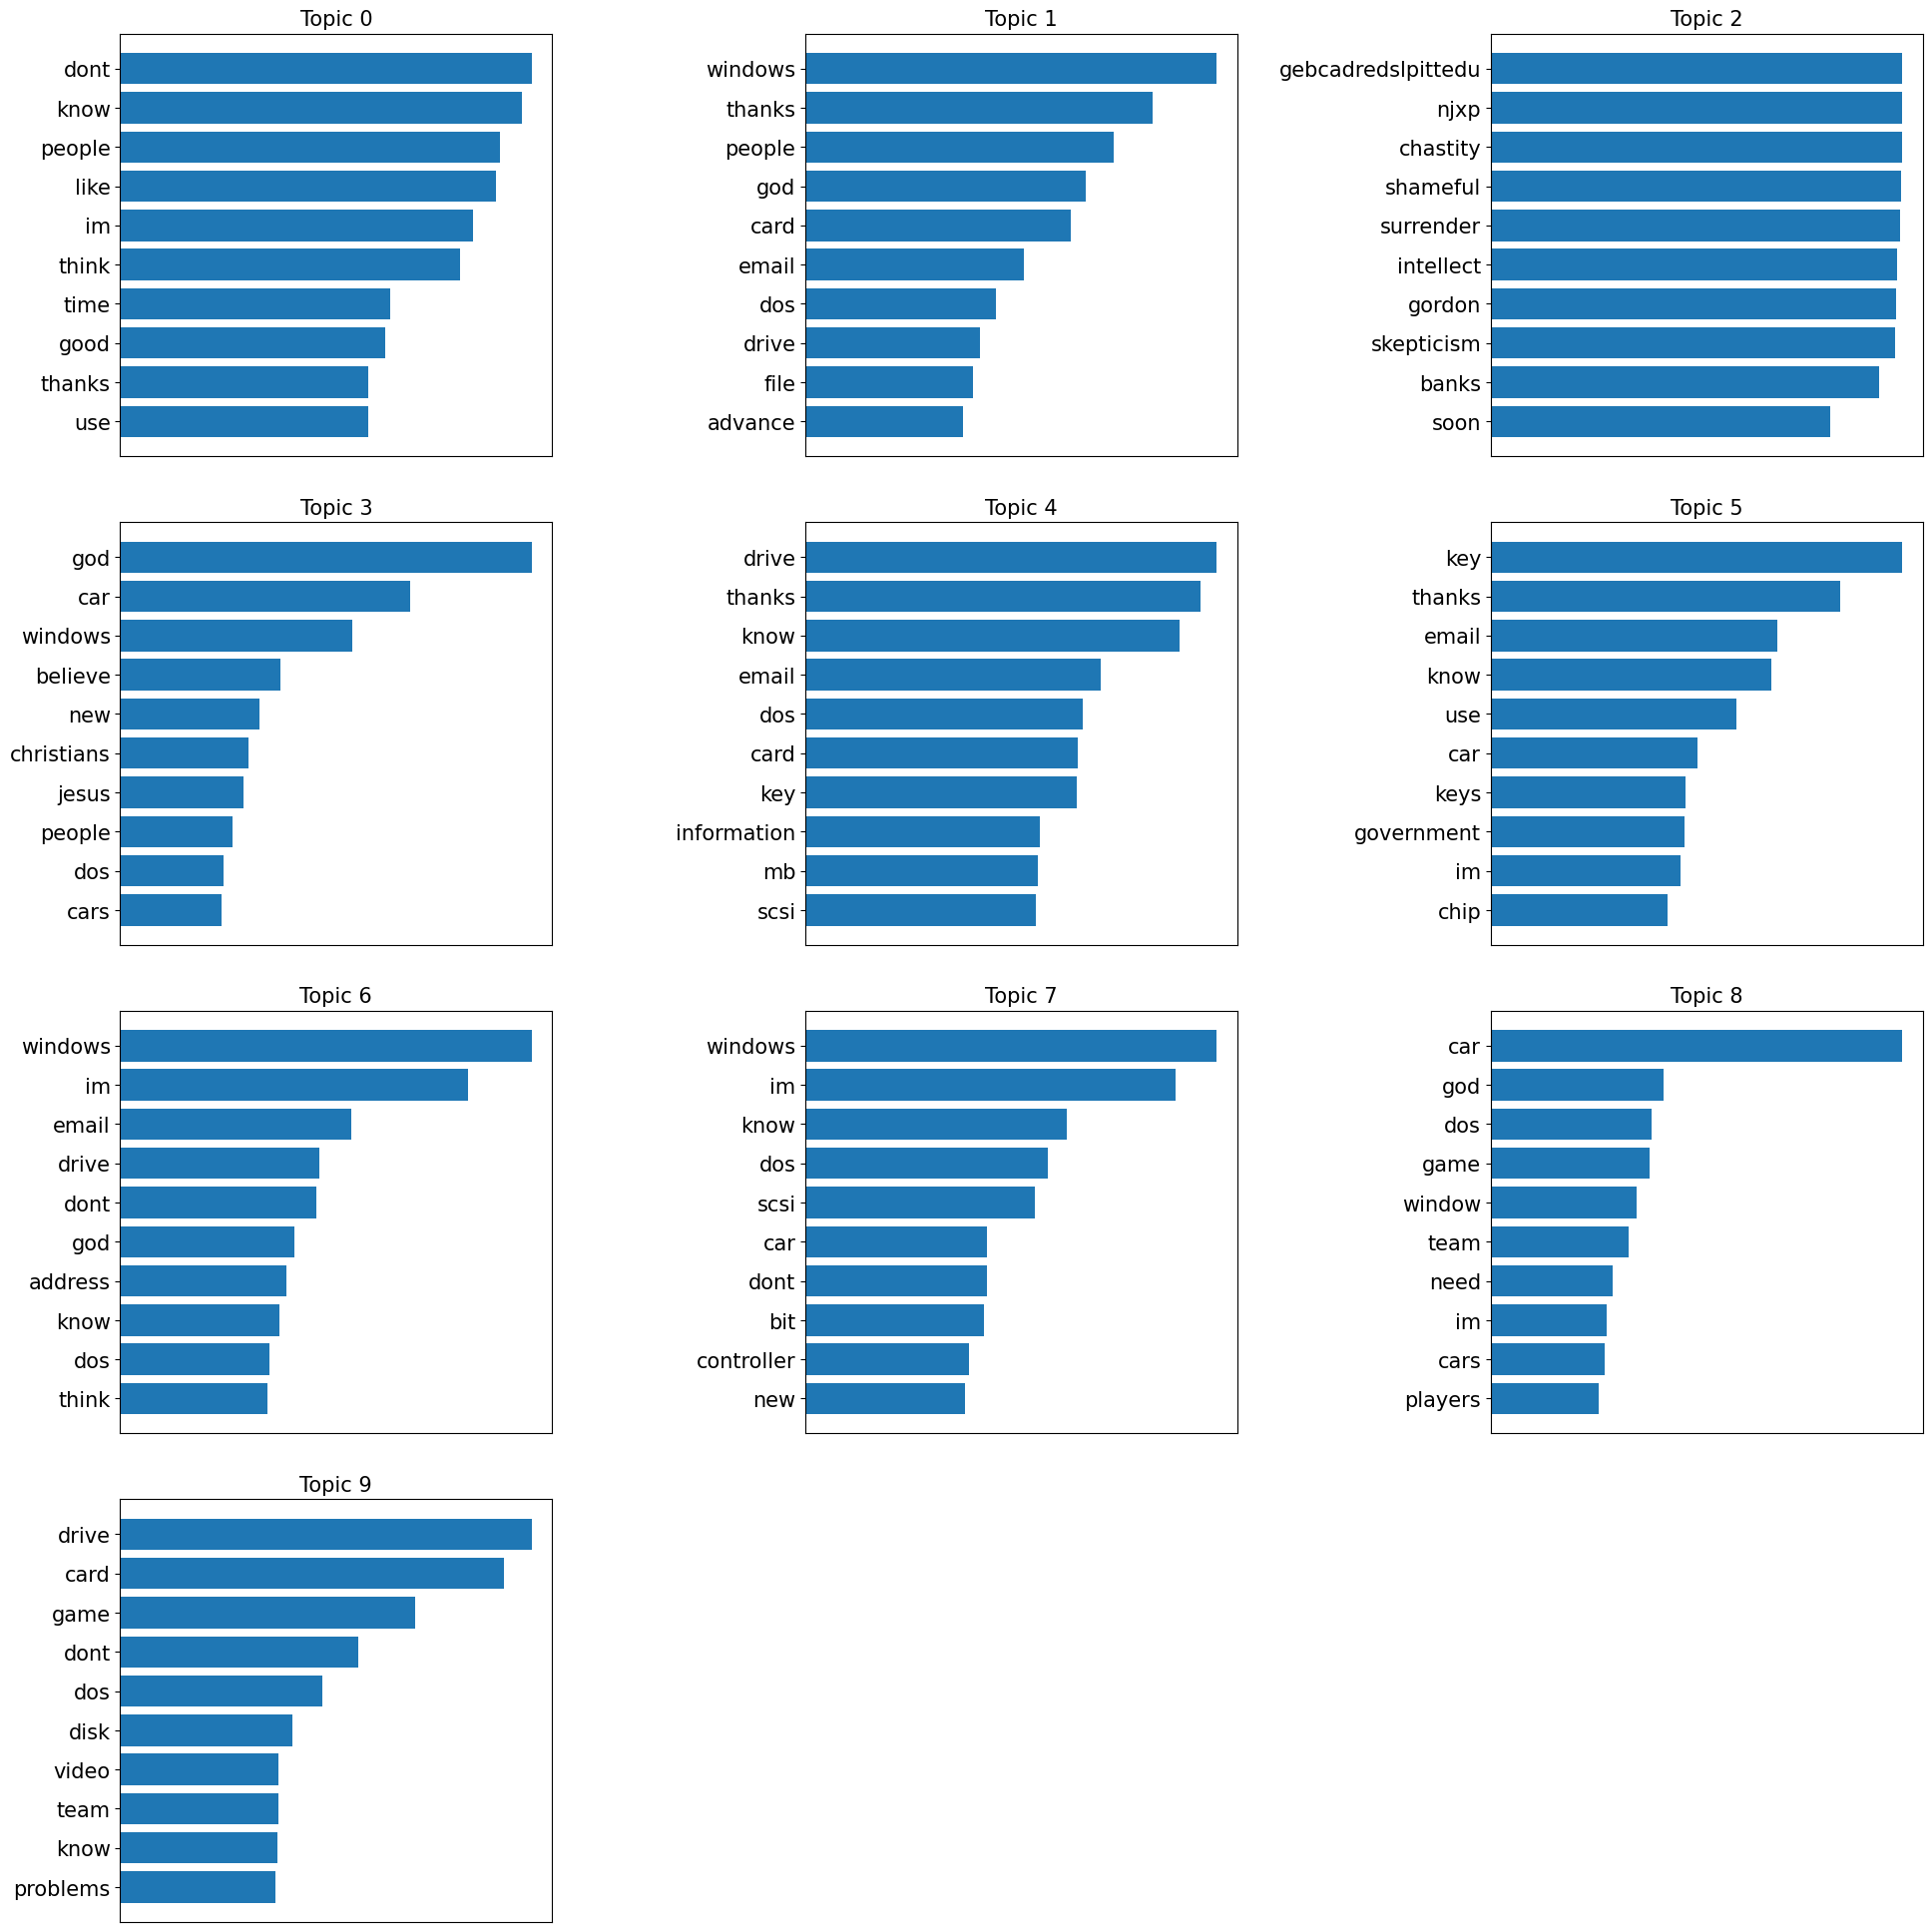

In [ ]:
# LSA Topic Visualization
import matplotlib.pyplot as plt
import numpy as np

n_topics = len(final_topics_lsa)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols

plt.figure(figsize=(20, 20))

for i in range(n_topics):
    plt.subplot(n_rows, n_cols, i + 1)

    topic_weights = lsa_final.components_[i]

    top_indices = np.argsort(np.abs(topic_weights))[:-11:-1]

    words = [feature_names_lsa[j] for j in top_indices]
    scores = topic_weights[top_indices]

    plt.barh(words[::-1], np.abs(scores)[::-1])

    plt.title(f"Topic {i}", fontsize=15)
    plt.xticks([])
    plt.yticks(fontsize=15)

plt.tight_layout(pad=3.0)
plt.show()

# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [ ]:
# For this question, I used the dataset containing 1000 movie reviews collected in my previous assignment. The clean_text column was used for BERTopic modeling.
import pandas as pd
import numpy as np
np.unicode_ = np.str_
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import nltk
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [ ]:
# Load dataset
df = pd.read_csv("imdb_1000_reviews_cleaned.csv")

# Keep only the clean_text column
df = df[["clean_text"]].copy()

# Remove null values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Check result
df.head()

,clean_text
0,hugh jackman perfect wolverine fun movie like ...
1,crazy blast bonkers sooo say movie whole team ...
2,many easter egg true comic character may possi...
3,painful watch movie time deadpool known crude ...
4,weve waited long moment beyond fun wholesome f...


In [ ]:
# Prepare documents
docs = df["clean_text"].tolist()

# Tokenized version for coherence calculation
tokenized_docs = [doc.split() for doc in docs]

# Build dictionary for gensim coherence
dictionary = Dictionary(tokenized_docs)

# Embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Vectorizer
vectorizer_model =CountVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.8,
    ngram_range=(1,2)
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# -----------------------------
# 1: Generate K=10 topics
# -----------------------------
topic_model_k10 = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=10,  # force reduction to 10 topics
    calculate_probabilities=True,
    verbose=True
)

topics_k10, probs_k10 = topic_model_k10.fit_transform(docs)

# Topic info
topic_info_k10 = topic_model_k10.get_topic_info()
print(topic_info_k10)

2026-04-11 22:39:08,033 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-04-11 22:39:09,879 - BERTopic - Embedding - Completed ✓
2026-04-11 22:39:09,879 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-11 22:39:13,558 - BERTopic - Dimensionality - Completed ✓
2026-04-11 22:39:13,559 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-11 22:39:13,623 - BERTopic - Cluster - Completed ✓
2026-04-11 22:39:13,623 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-11 22:39:13,804 - BERTopic - Representation - Completed ✓
2026-04-11 22:39:13,805 - BERTopic - Topic reduction - Reducing number of topics
2026-04-11 22:39:13,811 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-11 22:39:13,988 - BERTopic - Representation - Completed ✓
2026-04-11 22:39:13,990 - BERTopic - Topic reduction - Reduced number of topics from 13 to 10


   Topic  Count                                          Name  \
0     -1    471                    -1_fight_little_want_logan   
1      0    185             0_superhero_logan_deadpools_thats   
2      1    121                    1_fight_people_real_boring   
3      2     68          2_reynolds hugh_banter_ride_sequence   
4      3     51               3_wasnt_want_actually_streaming   
5      4     36                   4_want_men_favorite_avenger   
6      5     26                 5_cast_favorite_blade_started   
7      6     18           6_endgame_fantastic_needed_big time   
8      7     13                7_raunchy_fighting_minute_hard   
9      8     10  8_expectation_disappointed_movie best_ticket   

                                      Representation  \
0  [fight, little, want, logan, people, superhero...   
1  [superhero, logan, deadpools, thats, xmen, fig...   
2  [fight, people, real, boring, thats, want, har...   
3  [reynolds hugh, banter, ride, sequence, finall...   
4  [

In [ ]:
# Display top words for each topic
for topic_id in topic_info_k10["Topic"]:
    if topic_id == -1:
        continue
    print(f"\nTopic {topic_id}:")
    print(topic_model_k10.get_topic(topic_id))


Topic 0:
[('superhero', np.float64(0.02032910954168931)), ('logan', np.float64(0.013875414983958563)), ('deadpools', np.float64(0.013422227626225686)), ('thats', np.float64(0.013004082466890839)), ('xmen', np.float64(0.012443659658729784)), ('fight', np.float64(0.011898897948763561)), ('work', np.float64(0.01185319213321793)), ('sequence', np.float64(0.011564046864069985)), ('emotional', np.float64(0.0113300240565132)), ('little', np.float64(0.010838516266085962))]

Topic 1:
[('fight', np.float64(0.0200675497442153)), ('people', np.float64(0.019658039877855957)), ('real', np.float64(0.018931700438310415)), ('boring', np.float64(0.018447104569080063)), ('thats', np.float64(0.016179186490213354)), ('want', np.float64(0.015085389620646)), ('hard', np.float64(0.014972965955981814)), ('pretty', np.float64(0.014374288768335537)), ('fight scene', np.float64(0.013773928987865556)), ('script', np.float64(0.012554408217622702))]

Topic 2:
[('reynolds hugh', np.float64(0.023977082545118947)), ('

In [ ]:
# Create a simple interpretation table
topic_summaries = []

for topic_id in topic_info_k10["Topic"]:
    if topic_id == -1:
        continue

    words = [word for word, _ in topic_model_k10.get_topic(topic_id)[:10]]
    topic_summaries.append({
        "Topic": topic_id,
        "Top_Words": ", ".join(words)
    })

topic_summary_df = pd.DataFrame(topic_summaries)
topic_summary_df

,Topic,Top_Words
0,0,"superhero, logan, deadpools, thats, xmen, figh..."
1,1,"fight, people, real, boring, thats, want, hard..."
2,2,"reynolds hugh, banter, ride, sequence, finally..."
3,3,"wasnt, want, actually, streaming, watch movie,..."
4,4,"want, men, favorite, avenger, people, marvel f..."
5,5,"cast, favorite, blade, started, review movie, ..."
6,6,"endgame, fantastic, needed, big time, glad, mo..."
7,7,"raunchy, fighting, minute, hard, turn, people,..."
8,8,"expectation, disappointed, movie best, ticket,..."


In [ ]:
# -----------------------------------------
# 2: Find optimal K using coherence
# -----------------------------------------

def compute_topic_coherence(topic_model, docs_tokenized, dictionary):
    """
    Compute c_v coherence for a BERTopic model.
    Excludes outlier topic -1.
    """
    topic_words = []

    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
        if len(words) > 0:
            topic_words.append(words)

    if len(topic_words) == 0:
        return None

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=docs_tokenized,
        dictionary=dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence()

In [ ]:
# Try different K values
candidate_k = [5, 10, 15, 20, 25, 30, 35]
coherence_scores = []

for k in candidate_k:
    print(f"\nTraining BERTopic with K={k} ...")

    model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=k,
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = model.fit_transform(docs)
    coherence = compute_topic_coherence(model, tokenized_docs, dictionary)

    coherence_scores.append(coherence)
    print(f"K={k}, Coherence={coherence:.4f}")


Training BERTopic with K=5 ...
K=5, Coherence=0.3266

Training BERTopic with K=10 ...
K=10, Coherence=0.3387

Training BERTopic with K=15 ...
K=15, Coherence=0.3720

Training BERTopic with K=20 ...
K=20, Coherence=0.3915

Training BERTopic with K=25 ...
K=25, Coherence=0.3008

Training BERTopic with K=30 ...
K=30, Coherence=0.3785

Training BERTopic with K=35 ...
K=35, Coherence=0.3517


In [ ]:
# Results table
coherence_df = pd.DataFrame({
    "K": candidate_k,
    "Coherence": coherence_scores
})

print(coherence_df)

    K  Coherence
0   5   0.326629
1  10   0.338729
2  15   0.372036
3  20   0.391497
4  25   0.300795
5  30   0.378530
6  35   0.351748


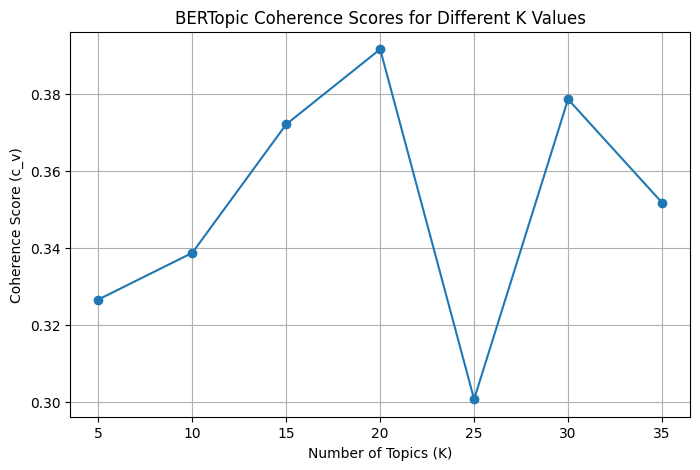

In [ ]:
# Plot coherence scores
plt.figure(figsize=(8, 5))
plt.plot(candidate_k, coherence_scores, marker="o")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("BERTopic Coherence Scores for Different K Values")
plt.grid(True)
plt.show()

In [ ]:
# Best K
best_k = candidate_k[np.argmax(coherence_scores)]
best_coherence = max(coherence_scores)

print(f"Optimal K based on coherence score: {best_k}")
print(f"Best coherence score: {best_coherence:.4f}")

Optimal K based on coherence score: 20
Best coherence score: 0.3915


In [ ]:
# -----------------------------------------
# Part 3: Retrain BERTopic with optimal K
# -----------------------------------------
topic_model_optimal = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=best_k,
    calculate_probabilities=True,
    verbose=True
)

topics_opt, probs_opt = topic_model_optimal.fit_transform(docs)

topic_info_opt = topic_model_optimal.get_topic_info()
topic_info_opt

2026-04-11 22:46:33,449 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-04-11 22:46:35,240 - BERTopic - Embedding - Completed ✓
2026-04-11 22:46:35,241 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-11 22:46:38,840 - BERTopic - Dimensionality - Completed ✓
2026-04-11 22:46:38,842 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-11 22:46:38,903 - BERTopic - Cluster - Completed ✓
2026-04-11 22:46:38,904 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-11 22:46:39,132 - BERTopic - Representation - Completed ✓
2026-04-11 22:46:39,133 - BERTopic - Topic reduction - Reducing number of topics
2026-04-11 22:46:39,134 - BERTopic - Topic reduction - Number of topics (20) is equal or higher than the clustered topics(10).
2026-04-11 22:46:39,136 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-11 22:46:39,365 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,447,-1_ryan_reynolds_ryan reynolds_disney,"[ryan, reynolds, ryan reynolds, disney, people...",[deadpool wolverine marvel film come year need...
1,0,45,0_rating_start_dont know_isnt,"[rating, start, dont know, isnt, script, trash...",[film released year movie goer going see regar...
2,1,48,1_people_entertainment_music_lame,"[people, entertainment, music, lame, action gr...",[watched yesterday big screen well yeah fun fl...
3,2,191,2_reynolds_ryan_ryan reynolds_logan,"[reynolds, ryan, ryan reynolds, logan, fox, xm...",[deadpool wolverine cinematic masterpiece seam...
4,3,11,3_raunchy_perfection_everybody_film feel,"[raunchy, perfection, everybody, film feel, ca...",[first deadpool witty second stretching joke o...
5,4,136,4_ryan_reynolds_ryan reynolds_reynolds hugh,"[ryan, reynolds, ryan reynolds, reynolds hugh,...",[ryan reynolds hugh jackman saved mcutoday wif...
6,5,42,5_review_avenger_men_people,"[review, avenger, men, people, ive, experience...",[deadpool wolverine dw first announced excited...
7,6,32,6_humour_ryan_money_ryan reynolds,"[humour, ryan, money, ryan reynolds, dead, str...",[ryan reynolds annoying listen long period tim...
8,7,22,7_ryan_reynolds_ryan reynolds_cast,"[ryan, reynolds, ryan reynolds, cast, blade, p...",[let talk elephant room reason movie rated r o...
9,8,25,8_review_hilarious_awesome_wasnt,"[review, hilarious, awesome, wasnt, super, ama...",[well honest review honestly say humble opinio...


In [ ]:
# Show top words for each topic in the optimal model
for topic_id in topic_info_opt["Topic"]:
    if topic_id == -1:
        continue
    print(f"\nOptimal Topic {topic_id}:")
    print(topic_model_optimal.get_topic(topic_id))


Optimal Topic 0:
[('rating', np.float64(0.021765493228137422)), ('start', np.float64(0.020808828327377273)), ('dont know', np.float64(0.020174247603707684)), ('isnt', np.float64(0.01980651815647589)), ('script', np.float64(0.018895154330629504)), ('trash', np.float64(0.016914047706232754)), ('stupid', np.float64(0.01680910042906029)), ('day', np.float64(0.016533260039300817)), ('quality', np.float64(0.016014077528610834)), ('super', np.float64(0.01587574100757261))]

Optimal Topic 1:
[('people', np.float64(0.027151130388082968)), ('entertainment', np.float64(0.01932011430149769)), ('music', np.float64(0.017515954729615767)), ('lame', np.float64(0.016423261775794052)), ('action great', np.float64(0.016423261775794052)), ('special', np.float64(0.015875110330063166)), ('good action', np.float64(0.015799342148401563)), ('effect', np.float64(0.01569747914843984)), ('idea', np.float64(0.01556973753743624)), ('forgettable', np.float64(0.015289928781707433))]

Optimal Topic 2:
[('reynolds', n

In [ ]:
# Save topic interpretations for the optimal model
optimal_topic_summaries = []

for topic_id in topic_info_opt["Topic"]:
    if topic_id == -1:
        continue

    words = [word for word, _ in topic_model_optimal.get_topic(topic_id)[:10]]
    optimal_topic_summaries.append({
        "Topic": topic_id,
        "Top_Words": ", ".join(words)
    })

optimal_topic_df = pd.DataFrame(optimal_topic_summaries)
optimal_topic_df

,Topic,Top_Words
0,0,"rating, start, dont know, isnt, script, trash,..."
1,1,"people, entertainment, music, lame, action gre..."
2,2,"reynolds, ryan, ryan reynolds, logan, fox, xme..."
3,3,"raunchy, perfection, everybody, film feel, cat..."
4,4,"ryan, reynolds, ryan reynolds, reynolds hugh, ..."
5,5,"review, avenger, men, people, ive, experience,..."
6,6,"humour, ryan, money, ryan reynolds, dead, stre..."
7,7,"ryan, reynolds, ryan reynolds, cast, blade, pr..."
8,8,"review, hilarious, awesome, wasnt, super, amaz..."


#### Interpretation

Topic 0: Negative opinions about the movie’s script and overall quality.

Topic 1: General discussion of entertainment value, including action, music, and overall enjoyment.

Topic 2: Discussion about Ryan Reynolds and connections to X-Men and Marvel franchises.

Topic 3: Audience reactions to the film’s style, including raunchy humor and overall tone.

Topic 4: Praise for Ryan Reynolds’ performance and comedic delivery.

Topic 5: Viewer experiences and opinions about superhero movies, including comparisons and IMAX viewing.

Topic 6: Discussion of humor, streaming experience, and mixed opinions about the movie.

Topic 7: Cast-related discussion, including Ryan Reynolds and references to Deadpool and Blade.

Topic 8: Positive reactions highlighting humor, entertainment, and overall enjoyment.

In [ ]:
# -----------------------------------------
# Part 4: Visualizations
# -----------------------------------------

# 1. Intertopic distance map
fig1 = topic_model_optimal.visualize_topics()
fig1.update_xaxes(autorange=True)
fig1.update_yaxes(autorange=True)
fig1.show()

The intertopic distance map shows that the topics form a few main clusters, which is reasonable for movie review data. However, there is significant overlap within each cluster, indicating that several topics are similar and somewhat redundant. Overall, the model captures the main themes, but topic separation could be improved.

In [ ]:
# 2. Bar chart of top words per topic
fig2 = topic_model_optimal.visualize_barchart(top_n_topics=10)
fig2.show()

The Topic Word Scores show that the model successfully identifies key themes in movie reviews, including sentiment (both positive and negative), entertainment value, and actor-related discussions (e.g., Ryan Reynolds). Overall, the topics are meaningful, but there is some redundancy, particularly among actor-related topics.

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

In [ ]:
# ---------------------------
# 1. Import libraries
# ---------------------------
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import re
import random
import warnings
import numpy as np
np.unicode_ = np.str_
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI as OpenAIClient

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import OpenAI

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

warnings.filterwarnings("ignore")

# ---------------------------
# Load OpenAI API key
# ---------------------------
# Put your key in a .env file like this:
# OPENAI_API_KEY=your_real_key_here
load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError(
        "OPENAI_API_KEY was not found. "
        "Please add it to your .env file or environment variables."
    )

# Create OpenAI client
client = OpenAIClient()

In [ ]:
# Load dataset
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

# Convert to DataFrame and sample 2000 documents
df = pd.DataFrame({'text': newsgroups.data})
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print("Number of documents:", len(df))

Number of documents: 2000


In [ ]:
# ---------------------------
# Text cleaning function
# ---------------------------
def clean_doc(doc: str) -> str:
    if not isinstance(doc, str):
        return ""

    doc = doc.lower()
    doc = re.sub(r"http\S+|www\S+", " ", doc)              # remove URLs
    doc = re.sub(r"\S+@\S+", " ", doc)                     # remove emails
    doc = re.sub(r"[^a-z\s]", " ", doc)                   # keep only letters/spaces
    doc = re.sub(r"\b[a-z]\b", " ", doc)                  # remove single letters
    doc = re.sub(r"\s+", " ", doc).strip()                # normalize spaces
    return doc

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_doc)

# Remove empty rows after cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

# Documents for topic modeling
docs = df["clean_text"].tolist()

# ---------------------------
# Tokenize for coherence calculation
# ---------------------------
tokenized_docs = [doc.split() for doc in docs]

# Build gensim dictionary
dictionary = Dictionary(tokenized_docs)

# Filter extremes to remove extremely rare / overly common tokens
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Rebuild tokenized docs to include only words kept in dictionary
valid_tokens = set(dictionary.token2id.keys())
tokenized_docs = [[token for token in doc if token in valid_tokens] for doc in tokenized_docs]

# Also rebuild cleaned docs after dictionary filtering (optional but helpful)
docs_for_model = [" ".join(tokens) for tokens in tokenized_docs]

# Drop empty docs after filtering
filtered_docs = []
filtered_tokenized_docs = []
for d, t in zip(docs_for_model, tokenized_docs):
    if len(t) > 0:
        filtered_docs.append(d)
        filtered_tokenized_docs.append(t)

docs_for_model = filtered_docs
tokenized_docs = filtered_tokenized_docs

In [ ]:
# ---------------------------
# Embedding model
# ---------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ---------------------------
# Vectorizer for BERTopic
# ---------------------------
vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)
)

# ---------------------------
#  compute coherence from a BERTopic model
# ---------------------------
def compute_coherence(topic_model, texts, dictionary, top_n_words=10):
    """
    Compute c_v coherence for BERTopic topics.
    Excludes outlier topic -1.
    """
    topic_info = topic_model.get_topic_info()

    valid_topic_ids = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()

    topic_words = []
    for topic_id in valid_topic_ids:
        words_scores = topic_model.get_topic(topic_id)
        if words_scores is None:
            continue

        # Extract only the words
        words = [word for word, score in words_scores[:top_n_words]]
        # Keep only words present in gensim dictionary
        words = [w for w in words if w in dictionary.token2id]

        if len(words) > 1:
            topic_words.append(words)

    if len(topic_words) == 0:
        return -1

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()

# ---------------------------
# Search for the best number of topics
# ---------------------------
# We first use the default representation during the search phase
# for efficiency. After finding the best topic count, we retrain
# the final model with OpenAI-based representation.
candidate_topic_counts = [5, 10, 15, 20, 25]
results = []

for k in candidate_topic_counts:
    print(f"\nTraining trial model with nr_topics={k} ...")

    trial_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=k,
        calculate_probabilities=True,
        verbose=False
    )

    trial_topics, trial_probs = trial_model.fit_transform(docs_for_model)

    score = compute_coherence(
        topic_model=trial_model,
        texts=tokenized_docs,
        dictionary=dictionary,
        top_n_words=10
    )

    valid_topic_count = len([t for t in trial_model.get_topic_info()["Topic"].tolist() if t != -1])

    results.append({
        "nr_topics": k,
        "coherence_score": score,
        "valid_topics_found": valid_topic_count
    })

    print(f"nr_topics={k}, coherence={score:.4f}, valid_topics_found={valid_topic_count}")

results_df = pd.DataFrame(results).sort_values(by="coherence_score", ascending=False).reset_index(drop=True)

print("\n=== Coherence Search Results ===")
print(results_df)

best_k = int(results_df.loc[0, "nr_topics"])
best_search_score = float(results_df.loc[0, "coherence_score"])

print(f"\nBest number of topics based on coherence: {best_k}")
print(f"Best search coherence score: {best_search_score:.4f}")


Training trial model with nr_topics=5 ...
nr_topics=5, coherence=0.3583, valid_topics_found=4

Training trial model with nr_topics=10 ...
nr_topics=10, coherence=0.5220, valid_topics_found=9

Training trial model with nr_topics=15 ...
nr_topics=15, coherence=0.5027, valid_topics_found=14

Training trial model with nr_topics=20 ...
nr_topics=20, coherence=0.5040, valid_topics_found=15

Training trial model with nr_topics=25 ...
nr_topics=25, coherence=0.5063, valid_topics_found=14

=== Coherence Search Results ===
   nr_topics  coherence_score  valid_topics_found
0         10         0.522018                   9
1         25         0.506342                  14
2         20         0.503956                  15
3         15         0.502707                  14
4          5         0.358316                   4

Best number of topics based on coherence: 10
Best search coherence score: 0.5220


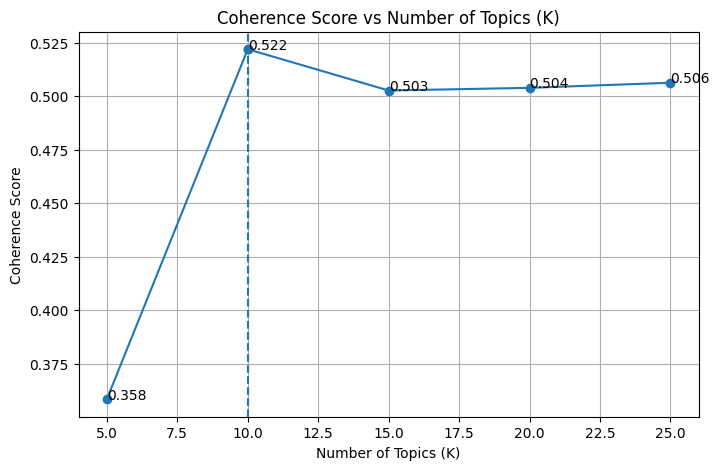

In [ ]:
import matplotlib.pyplot as plt
# Sort by number of topics so the line connects points in the correct order
plot_df = results_df.sort_values("nr_topics")

k_values = plot_df["nr_topics"]
coherence_scores = plot_df["coherence_score"]

plt.figure(figsize=(8, 5))
plt.plot(k_values, coherence_scores, marker='o')

# Highlight the best K
plt.axvline(x=best_k, linestyle='--')
plt.scatter(best_k, best_search_score)

plt.title("Coherence Score vs Number of Topics (K)")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")

# Add value labels for each point
for x, y in zip(k_values, coherence_scores):
    plt.text(x, y, f"{y:.3f}")

plt.grid()
plt.show()

In [ ]:
keyword_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=best_k,
    calculate_probabilities=True
)

topics_kw, probs_kw = keyword_model.fit_transform(docs_for_model)

In [ ]:
# ---------------------------
# Create OpenAI representation model
# ---------------------------

representation_model = OpenAI(
    client=client,
    model="gpt-4o-mini",
    chat=True,
    prompt="""
You are given a list of keywords representing a topic.

STRICT RULES:
1. Use the meaning of the provided keywords in each topic.
2. Identify the most probable topic represented by the keywords.
3. Do not introduce any concepts that are not present in the keywords.
4. Output a short label.

Now:
Keywords: [KEYWORDS]
Topic:
"""
)

# ---------------------------
# Retrain final BERTopic model
#     using optimal number of topics
#     and OpenAI representation
# ---------------------------
final_topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=best_k,
    representation_model=representation_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = final_topic_model.fit_transform(docs_for_model)

# ---------------------------
# Compute final coherence score
# ---------------------------
final_coherence = compute_coherence(
    topic_model=final_topic_model,
    texts=tokenized_docs,
    dictionary=dictionary,
    top_n_words=10
)
# ---------------------------
# 15. Show topic information
# ---------------------------
topic_info = final_topic_model.get_topic_info()

print("\n=== Final Topic Info ===")
print(topic_info)

2026-04-09 20:30:16,499 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

2026-04-09 20:30:25,680 - BERTopic - Embedding - Completed ✓
2026-04-09 20:30:25,681 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 20:30:28,360 - BERTopic - Dimensionality - Completed ✓
2026-04-09 20:30:28,362 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 20:30:28,446 - BERTopic - Cluster - Completed ✓
2026-04-09 20:30:28,446 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-09 20:30:28,643 - BERTopic - Representation - Completed ✓
2026-04-09 20:30:28,643 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 20:30:28,652 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 10/10 [00:06<00:00,  1.57it/s]
2026-04-09 20:30:35,257 - BERTopic - Representation - Completed ✓
2026-04-09 20:30:35,271 - BERTopic - Topic reduction - Reduced number of topics from 16 to 10



=== Final Topic Info ===
   Topic  Count                                               Name  \
0     -1    229          -1_Conspiracy Theories and Misinformation   
1      0    630  0_Software and Memory Management for PCs and Macs   
2      1    343                           1_Military Space Mission   
3      2    177                  2_Christianity and Belief Systems   
4      3    160        3_Gun Control and Government Administration   
5      4    146               4_Baseball Rivalries and Performance   
6      5     87                5_Child Health and Medical Research   
7      6     75             6_Data Encryption and Security Systems   
8      7     74              7_Conflict and Human Rights in Russia   
9      8     27                           8_Testing and Evaluation   

                                      Representation  \
0           [Conspiracy Theories and Misinformation]   
1  [Software and Memory Management for PCs and Macs]   
2                           [Milita

In [ ]:
# ---------------------------
# Print topic summaries
# ---------------------------
print("\n=== Topic Summaries ===")
for topic_id in topic_info["Topic"].tolist():
    if topic_id == -1:
        continue

    print(f"\nTopic {topic_id}")
    print("-" * 50)

    topic_name = topic_info[topic_info["Topic"] == topic_id]["Name"].values[0]
    print("GPT Summary:", topic_name)

    topic_terms = keyword_model.get_topic(topic_id)

    if not topic_terms:
        print("Top words: Not available")
        continue

    # Top 10 keywords
    top_words = [word for word, score in topic_terms[:10]]
    print("Top words:", ", ".join(top_words))


=== Topic Summaries ===

Topic 0
--------------------------------------------------
GPT Summary: 0_Software and Memory Management for PCs and Macs
Top words: max, use, bit, mac, available, software, thanks, file, like, problem

Topic 1
--------------------------------------------------
GPT Summary: 1_Military Space Mission
Top words: space, car, new, south, war, like, time, secret, cars, good

Topic 2
--------------------------------------------------
GPT Summary: 2_Christianity and Belief Systems
Top words: la, vs, team, game, year, season, games, play, player, think

Topic 3
--------------------------------------------------
GPT Summary: 3_Gun Control and Government Administration
Top words: god, church, jesus, believe, faith, christian, christians, does, say, people

Topic 4
--------------------------------------------------
GPT Summary: 4_Baseball Rivalries and Performance
Top words: president, mr, ms, think, gun, don, going, administration, package, government

Topic 5
----------

#### The model performs well for clearly defined topics such as software, health, cybersecurity, and war. However, it still struggles with topics that are semantically related or commonly confused, such as sports, religion, and politics. This was mainly due to noisy keywords and insufficient prompt constraints.

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [ ]:
# Q4: BERTopic customization and comparison

import re
import numpy as np
np.unicode_ = np.str_
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer

from bertopic import BERTopic

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [ ]:
# Load dataset
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

# Convert to DataFrame and sample 2000 documents
df = pd.DataFrame({'text': newsgroups.data})
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print("Number of documents:", len(df))

Number of documents: 2000


In [ ]:
# Simple text cleaning function
def clean_text(text):
    text = text.lower()                          # convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # remove punctuation and numbers
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Keep only meaningful texts
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

docs = df["clean_text"].tolist()

In [ ]:
# Tokenize documents for coherence calculation
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]


def get_valid_topics(topic_model):
    """
    Return all valid topic IDs, excluding the outlier topic -1.
    """
    topic_info = topic_model.get_topic_info()
    valid_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()
    return valid_topics


def extract_topic_words(topic_model, top_n=10):
    """
    Extract top words for each valid topic in the format required by Gensim coherence.
    """
    topic_words = []
    valid_topics = get_valid_topics(topic_model)

    for topic_id in valid_topics:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n]]
        if len(words) > 0:
            topic_words.append(words)

    return topic_words


def compute_coherence(topic_model, tokenized_docs, dictionary, coherence_type="c_v", top_n=10):
    """
    Compute topic coherence score.
    """
    topic_words = extract_topic_words(topic_model, top_n=top_n)

    if len(topic_words) == 0:
        return None

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence_type
    )
    return coherence_model.get_coherence()


def print_sample_topics(topic_model, model_name, n_topics=5, top_n_words=10):
    """
    Print a few sample topics for interpretation.
    """
    print(f"\nSample topics from {model_name}:")
    valid_topics = get_valid_topics(topic_model)[:n_topics]

    for topic_id in valid_topics:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        print(f"Topic {topic_id}: {', '.join(words)}")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=2,
    max_df=0.85,
    ngram_range=(1,2)
)

# Default BERTopic model
default_topic_model = BERTopic(vectorizer_model=vectorizer_model, verbose=True)

# Fit model
default_topics, default_probs = default_topic_model.fit_transform(docs)

# Topic info
default_topic_info = default_topic_model.get_topic_info()

2026-04-11 17:50:34,772 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

2026-04-11 17:50:40,724 - BERTopic - Embedding - Completed ✓
2026-04-11 17:50:40,726 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-11 17:50:47,251 - BERTopic - Dimensionality - Completed ✓
2026-04-11 17:50:47,252 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-11 17:50:47,306 - BERTopic - Cluster - Completed ✓
2026-04-11 17:50:47,309 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-11 17:50:47,785 - BERTopic - Representation - Completed ✓


In [ ]:
default_topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,293,-1_max_mr_pl_myers,"[max, mr, pl, myers, president, ms, wm, war, k...",[the white house office of the press secretary...
1,0,614,0_dos_windows_bit_mb,"[dos, windows, bit, mb, mac, edu, available, c...",[hello i thought this problem might have somet...
2,1,197,1_car_bike_cars_engine,"[car, bike, cars, engine, dog, road, riding, m...",[ds from viking iastate edu dan sorenson ds ri...
3,2,163,2_god_church_jesus_christ,"[god, church, jesus, christ, religion, christi...",[ok here s at least one christian s answer jes...
4,3,119,3_space_nasa_lunar_orbit,"[space, nasa, lunar, orbit, moon, mars, earth,...",[ssf is up for redesign again let s do it righ...
5,4,87,4_pain_health_jb_medical,"[pain, health, jb, medical, insurance, msg, sa...",[morphine or demerol is about the only effecti...
6,5,84,5_la_pt_vs_gm,"[la, pt, vs, gm, team, game, games, season, pl...",[st round pitt vs nyi pitt in it looks like a ...
7,6,68,6_key_clipper_encryption_keys,"[key, clipper, encryption, keys, chip, governm...",[archive name ripem attacks last update mar so...
8,7,65,7_cubs_suck_player_team,"[cubs, suck, player, team, hit, year, game, pl...",[we have no way of knowing because we cannot s...
9,8,49,8_israel_tyre_jews_war,"[israel, tyre, jews, war, rights, country, pea...",[many of you ask me whether i approve of sever...


In [ ]:
# Coherence
default_coherence = compute_coherence(default_topic_model, tokenized_docs, dictionary)
print("\nDefault BERTopic coherence score:", default_coherence)


Default BERTopic coherence score: 0.6016705862641756


In [ ]:
# Print sample topics
print_sample_topics(default_topic_model, "Default BERTopic")


Sample topics from Default BERTopic:
Topic 0: dos, windows, bit, mb, mac, edu, available, com, software, thanks
Topic 1: car, bike, cars, engine, dog, road, riding, mph, miles, speed
Topic 2: god, church, jesus, christ, religion, christians, faith, christian, say, hell
Topic 3: space, nasa, lunar, orbit, moon, mars, earth, mission, probe, missions
Topic 4: pain, health, jb, medical, insurance, msg, safety, increased, child, age


In [ ]:
# Use a Sentence-Transformers embedding model
embedding_model = SentenceTransformer("all-mpnet-base-v2")
#
# Create embeddings first
embeddings = embedding_model.encode(docs, show_progress_bar=True)

# DBSCAN clustering instead of HDBSCAN
cluster_model = DBSCAN(
    eps=0.3,
    min_samples=8
)

# CountVectorizer for topic word extraction

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=2,
    max_df=0.85,
    ngram_range=(1,2)
)


# Custom BERTopic model
custom_topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=cluster_model,   # BERTopic accepts custom clustering model here
    vectorizer_model=vectorizer_model,
    verbose=True
)

# Fit custom model
custom_topics, custom_probs = custom_topic_model.fit_transform(docs, embeddings)

# Topic info
custom_topic_info = custom_topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

2026-04-11 17:51:43,862 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-11 17:51:52,770 - BERTopic - Dimensionality - Completed ✓
2026-04-11 17:51:52,771 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-11 17:51:52,792 - BERTopic - Cluster - Completed ✓
2026-04-11 17:51:52,795 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-11 17:51:53,305 - BERTopic - Representation - Completed ✓


In [ ]:
custom_topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,160,-1_windows_ma_files_marriage,"[windows, ma, files, marriage, mouse, photogra...",[these word processing utilities all include c...
1,0,249,0_dos_mb_mac_drive,"[dos, mb, mac, drive, mhz, ibm, os, pc, disk, ...",[from sam halperin cccbbs uceng dx mhz in zero...
2,1,206,1_car_bike_cars_engine,"[car, bike, cars, engine, dog, road, mph, ridi...",[i ll tell you my story as an example of what ...
3,2,183,2_president_myers_mr_ms,"[president, myers, mr, ms, people, gun, admini...",[the white house office of the press secretary...
4,3,169,3_god_church_believe_jesus,"[god, church, believe, jesus, christ, people, ...",[i have found jewish people very imagentative ...


In [ ]:
# Coherence
custom_coherence = compute_coherence(custom_topic_model, tokenized_docs, dictionary)
print("\nCustom BERTopic coherence score:", custom_coherence)


Custom BERTopic coherence score: 0.6195169819514676


In [ ]:
# Print sample topics
print_sample_topics(custom_topic_model, "Custom BERTopic (Sentence-Transformers + DBSCAN)")


Sample topics from Custom BERTopic (Sentence-Transformers + DBSCAN):
Topic 0: dos, mb, mac, drive, mhz, ibm, os, pc, disk, controller
Topic 1: car, bike, cars, engine, dog, road, mph, riding, miles, speed
Topic 2: president, myers, mr, ms, people, gun, administration, package, said, government
Topic 3: god, church, believe, jesus, christ, people, christian, christians, religion, faith
Topic 4: la, pt, vs, team, game, players, season, gm, games, play


In [ ]:
# Number of valid topics
default_valid_topics = len(get_valid_topics(default_topic_model))
custom_valid_topics = len(get_valid_topics(custom_topic_model))

# Number of outliers
default_outliers = sum(np.array(default_topics) == -1)
custom_outliers = sum(np.array(custom_topics) == -1)

# Comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Default BERTopic",
        "Custom BERTopic (Sentence-Transformers + DBSCAN)"
    ],
    "Valid Topics": [
        default_valid_topics,
        custom_valid_topics
    ],
    "Outlier Documents": [
        default_outliers,
        custom_outliers
    ],
    "Coherence Score (c_v)": [
        default_coherence,
        custom_coherence
    ]
})

print(comparison_df)

                                              Model  Valid Topics  \
0                                  Default BERTopic            19   
1  Custom BERTopic (Sentence-Transformers + DBSCAN)            20   

   Outlier Documents  Coherence Score (c_v)  
0                293               0.601671  
1                160               0.619517  


#### Comparison Summary:

The default BERTopic model achieved a coherence score of 0.6017, which is slightly lower than the custom model’s score of 0.6195, indicating that the custom model produces more semantically consistent topics. In terms of clustering behavior, the default model generated 19 valid topics with a higher number of outlier documents, whereas the custom model produced 20 topics with fewer outliers. This suggests that the DBSCAN clustering algorithm used in the custom model is able to better assign documents to topics while maintaining a similar level of topic granularity.

In terms of interpretability, both models generate meaningful and recognizable topics. The default model identifies several clear themes. For example, Topic 0 reflects a computer-related theme, with keywords such as “dos, windows, mac, and software,”, Topic 1 represents automobiles, with keywords such as “car, road, speed,” Topic 2 represents religion, with words like “god, church, faith,” and Topic 3 corresponds to space exploration, indicated by “space, nasa, mission.” and Topic 4 captures a health-related topic, as shown by “pain, medical, insurance.” These topics are generally well-balanced but sometimes include less specific or mixed keywords.

Similarly, the custom model also produces clear and meaningful topics. For instance, Topic 0 represents computer systems, with keywords like “dos, mac, pc, drive,” Topic 2 captures a political theme, indicated by “president, government, administration,” and Topic 3 represents religion with more consistent keywords such as “god, church, believe.” In addition, Topic 4 corresponds to sports, with words like “team, game, players.” Compared to the default model, the custom model produces more focused and domain-specific topics, especially in areas such as politics and technical systems.

Overall, the custom BERTopic model demonstrates better performance in terms of coherence and interpretability, while also reducing the number of outliers. This indicates improved clustering quality and more meaningful topic representations.

In [ ]:
# Default model
fig1 = default_topic_model.visualize_topics()
fig1.update_layout(
    width=600,
    height=500
)
fig1.show()

fig2 = default_topic_model.visualize_barchart(top_n_topics=5)
fig2.update_layout(
    width=800,
    height=500
)
fig2.show()

In [ ]:
# Custom model
fig3 = custom_topic_model.visualize_topics()
fig3.update_layout(
    width=600,
    height=500
)
fig3.show()

fig4 = custom_topic_model.visualize_barchart(top_n_topics=5)
fig4.update_layout(
    width=800,
    height=500
)
fig4.show()

### Qualitative analysis
#### The intertopic distance maps：
In the default model, topics are more spread out, and several large circles can be observed. This indicates that the model produces fewer but broader topics, with some overlap between them. The separation between topics is moderate, suggesting that some themes are not clearly distinguished.

In contrast, the custom model shows more compact and clustered topics, especially in the upper-left region, where multiple topics are grouped closely together. This suggests that the model creates more fine-grained topics, capturing subtle differences between similar themes. At the same time, some topics are clearly separated, such as the large cluster on the right, indicating well-defined and distinct topics.

Overall, the custom model provides better topic separation and more detailed clustering, while the default model produces more general and broader topics. This reflects a trade-off between granularity and simplicity in topic modeling.
#### The bar charts：
In the default model, the topics are generally clear but sometimes contain mixed or less specific words. For example, Topic 0 includes words like “dos, windows, mac”, which relate to computer systems but also include some less informative terms. Topic 1 clearly represents a vehicle-related topic with words like “car, bike, engine”, and Topic 4 combines health-related terms such as “pain, medical, insurance”, which are somewhat broad.

In the custom model, the topics are more focused but still contain some noise. For example, Topic 0 clearly represents computer systems with words like “dos, mac, drive, mhz”. Topic 1 remains a vehicle-related topic and is similar to the default model. Topic 2 captures a political-related theme with words like “president”, but also includes less meaningful terms such as names and titles (“myers, mr, ms”), indicating some noise in the topic. Topic 4 represents sports with words like “team, game”, which is clear and easy to interpret.

Overall, the custom model produces more specific and focused topics, although some noise still exists. Compared to the default model, it provides clearer topic separation and improved interpretability.

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

Among the four topic modeling algorithms (LDA, LSA, BERTopic, and Modified BERTopic), the Modified BERTopic model performs the best overall.

From a quantitative perspective, the Modified BERTopic achieves the highest coherence score (0.6195), followed by the default BERTopic (0.6017), LDA (0.5761), and LSA (0.5340). Since coherence (c_v) measures the semantic consistency of topic keywords, this result indicates that the modified model produces the most meaningful and coherent topics.

The superior performance of the Modified BERTopic model is mainly due to two key improvements. First, it uses a more powerful embedding model, “all-mpnet-base-v2”, which captures semantic relationships between words and documents more effectively than the default “all-MiniLM-L6-v2”. Second, the clustering algorithm is changed from the default HDBSCAN to DBSCAN, allowing more flexible control over how documents are grouped into topics. These modifications improve both semantic representation and clustering quality.

Compared to the default BERTopic, the modified model also produces fewer outlier documents (160 vs. 293), indicating better assignment of documents to topics and improved clustering stability. In addition, the number of topics is similar (20 vs. 19), suggesting that the model maintains a good balance between topic granularity and interpretability.

LDA performs reasonably well with a coherence score of 0.5761 at the optimal K=10. This is because LDA is based on word co-occurrence, which aligns well with the c_v coherence metric. However, LDA requires manually specifying the number of topics and does not capture contextual semantic meaning as effectively as embedding-based methods.

LSA shows the weakest performance with a coherence score of 0.5340. Since LSA relies on matrix decomposition rather than probabilistic modeling or contextual embeddings, its topics are often less interpretable and less semantically coherent.

In conclusion, while traditional methods such as LDA and LSA provide useful baselines, BERTopic-based models outperform them, and the Modified BERTopic model is the best overall due to its improved semantic representation and clustering strategy.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
# Your answer here (no code for this question, write down your answer as detail as possible for the above questions):
'''
This exercise helped me better understand how to work with text data and apply different topic modeling algorithms. By using LDA, LSA, BERTopic, and a modified BERTopic model, I learned how different methods extract topics from text. Traditional methods like LDA and LSA mainly rely on word frequency, while BERTopic uses embeddings to capture meaning. This made it easier to see how modern NLP methods improve topic quality.

One challenge I faced was tuning the models and understanding the results. For example, in LDA and LSA, some topics were hard to interpret. In BERTopic, I needed to understand how embeddings and clustering work together. Using DBSCAN was also challenging because small parameter changes greatly affected the results, sometimes producing too few topics or unbalanced clusters.

This exercise is very relevant to NLP because topic modeling is widely used to analyze large text datasets. It is useful for tasks like document classification, recommendation systems, and information retrieval. Overall, this assignment helped me understand how different topic modeling methods work and why both model design and parameter tuning are important.
'''

'\nThis exercise helped me better understand how to work with text data and apply different topic modeling algorithms. By using LDA, LSA, BERTopic, and a modified BERTopic model, I learned how different methods extract topics from text. Traditional methods like LDA and LSA mainly rely on word frequency, while BERTopic uses embeddings to capture meaning. This made it easier to see how modern NLP methods improve topic quality.\n\nOne challenge I faced was tuning the models and understanding the results. For example, in LDA and LSA, some topics were hard to interpret. In BERTopic, I needed to understand how embeddings and clustering work together. Using DBSCAN was also challenging because small parameter changes greatly affected the results, sometimes producing too few topics or unbalanced clusters.\n\nThis exercise is very relevant to NLP because topic modeling is widely used to analyze large text datasets. It is useful for tasks like document classification, recommendation systems, and 